# ForceSMIP Challenge - Tier 2

This notebook demonstrates the ForceSMIP evaluation on Tier 2

## 1. Setup and Imports

In [ ]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('notebooks'), '..', 'ForceSMIP')))

# Import our modules
from data_loader import ForceSMIPDataLoader
from preprocessing import (
    yearly_average, compute_yearly_average_dict,
    merge_training_data, reshape_training_data, 
    apply_notnan_filter_complete, capture_nans
)
from algorithms import WeightedRidgeRegression, ridge_regression, LowRankSolver
from evaluation import ForceSMIPEvaluator, compute_trends_from_data, compute_statistics
from visualization import ForceSMIPVisualizer
from forcesmip_pipeline import ForceSMIPPipeline

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Modules loaded successfully!")


Modules loaded successfully!


## 2.  Data path where there is forceSMIP data folder. 

In [ ]:
# Initialize pipeline
base_path = '/net/krypton/climdyn_nobackup/FTP'

# variable names: pr, psl, tas, tos
variable = 'pr'  # Precipitation

Pipeline initialized for variable: pr


## 3. Step-by-Step Analysis (Manual Pipeline)

### 3.1 Data Loading

In [3]:
# Initialize data loader
data_loader = ForceSMIPDataLoader(base_path)

# Load training data
print("Loading training data...")
dic_data, dic_forced_response, longitude, latitude = data_loader.load_training_data(variable)

print(f"Training data loaded:")
print(f"  Number of models: {len(dic_data)}")
print(f"  Model names: {list(dic_data.keys())}")
print(f"  Grid shape: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"  Time steps: {list(dic_data.values())[0].shape[1]}")

Loading training data...
Processing 1/5: CESM2
  Processing 1/50: pr_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: pr_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: pr_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: pr_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: pr_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: pr_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: pr_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: pr_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: pr_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: pr_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: pr_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: pr_mon_CESM2_histo

In [4]:
# Load test data
test_models = ['2A', '2B', '2C', '2D', '2E', '2F', '2G', '2H', '2I', '2J', '2K', '2L', '2M', '2N', '2O', '2P', '2Q', '2R', '2S', '2T', '2U']
print("\nLoading test data...")
data_test, temporal_means = data_loader.load_test_data(variable, tier='Tier2', test_models=test_models)


print(f"Test data shape: {data_test.shape}")


Loading test data...
Files in test data directory: ['pr_mon_2A.190001-202312.nc', 'pr_mon_2B.190001-202312.nc', 'pr_mon_2C.190001-202312.nc', 'pr_mon_2D.190001-202312.nc', 'pr_mon_2E.190001-202312.nc', 'pr_mon_2F.190001-202312.nc', 'pr_mon_2G.190001-202312.nc', 'pr_mon_2H.190001-202312.nc', 'pr_mon_2I.190001-202312.nc', 'pr_mon_2J.190001-202312.nc', 'pr_mon_2K.190001-202312.nc', 'pr_mon_2L.190001-202312.nc', 'pr_mon_2M.190001-202312.nc', 'pr_mon_2N.190001-202312.nc', 'pr_mon_2O.190001-202312.nc', 'pr_mon_2P.190001-202312.nc', 'pr_mon_2Q.190001-202312.nc', 'pr_mon_2R.190001-202312.nc', 'pr_mon_2S.190001-202312.nc', 'pr_mon_2T.190001-202312.nc', 'pr_mon_2U.190001-202312.nc']
Loading test data for 2A at index 0
create data_test array
Monthly centering
Loading test data for 2B at index 1


/home/vcohen/cope/ForceSMIP/data_loader.py:177: RuntimeWarning: Mean of empty slice
  monthly_mean = np.nanmean(data_tmp[month_mask, :, :], axis=0).squeeze()


Monthly centering
Loading test data for 2C at index 2
Monthly centering
Loading test data for 2D at index 3
Monthly centering
Loading test data for 2E at index 4
Monthly centering
Loading test data for 2F at index 5
Monthly centering
Loading test data for 2G at index 6
Monthly centering
Loading test data for 2H at index 7
Monthly centering
Loading test data for 2I at index 8
Monthly centering
Loading test data for 2J at index 9
Monthly centering
Loading test data for 2K at index 10
Monthly centering
Loading test data for 2L at index 11
Monthly centering
Loading test data for 2M at index 12
Monthly centering
Loading test data for 2N at index 13
Monthly centering
Loading test data for 2O at index 14
Monthly centering
Loading test data for 2P at index 15
Monthly centering
Loading test data for 2Q at index 16
Monthly centering
Loading test data for 2R at index 17
Monthly centering
Loading test data for 2S at index 18
Monthly centering
Loading test data for 2T at index 19
Monthly centering


# Data processing

In [5]:
# Compute yearly averages
print("Computing yearly averages...")
dic_data_yearly = compute_yearly_average_dict(dic_data)
dic_forced_response_yearly = compute_yearly_average_dict(dic_forced_response)

data_test_yearly = yearly_average(data_test)
# data_ground_truth_yearly = yearly_average(data_ground_truth)

print(f"Yearly data shape (first model): {list(dic_data_yearly.values())[0].shape}")
print(f"Test yearly shape: {data_test_yearly.shape}")

Computing yearly averages...


Yearly data shape (first model): (50, 221, 72, 144)
Test yearly shape: (21, 124, 72, 144)


/home/vcohen/cope/ForceSMIP/data_loader.py:309: RuntimeWarning: Mean of empty slice
  return np.nanmean(data_reshaped, axis=2)


In [6]:
# Prepare training data for machine learning
print("Preparing training data...")

# Method 1: Merge all training data
x_train_merged, y_train_merged = merge_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

# Method 2: Keep model separation
x_train_dict, y_train_dict = reshape_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

print(f"Merged training data shape: X={x_train_merged.shape}, Y={y_train_merged.shape}")
print(f"Separated training data: {len(x_train_dict)} models")

Preparing training data...
Merged training data shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Separated training data: 5 models


# Capture the NaNs of the data

In [7]:
nan_idx, notnan_idx =capture_nans(x_train_dict)

# Prepare test data for smoothing experiments
x_test = torch.from_numpy(data_test.reshape(
    data_test.shape[0], data_test.shape[1], -1
)).to(torch.float32)

print(f"Test data shape for smoothing: {x_test.shape}")

Test data shape for smoothing: torch.Size([21, 1488, 10368])


In [8]:
# add the nans that are also included in the test data
# record nan indices as the union of nans on each map
nan_idx_test = nan_idx.copy()

for idx_r in range(x_test.shape[0]):

    # get nan mask of test set 
    nan_mask = np.where(np.abs(x_test[idx_r,:,:])>1e10, True, False)
    if nan_mask.any() == False:
        nan_mask = np.where(np.isnan(x_test[idx_r,:,:])==True, True, False)

    # get the index of columns where there is at least one True in the nan mask
    col_indices = np.where(np.any(nan_mask, axis=0))[0]

    nan_idx_test = list(set(nan_idx_test) | set(col_indices))    

# define not nan indices (useful to ease the computations)
notnan_idx_test = list(set(list(range(x_test.shape[2]))) - set(nan_idx_test))
    

# # replace the nan index by Nans
# if variable != 'tas':
#     notnan_idx = notnan_idx_test
#     nan_idx = nan_idx_test


/tmp/ipykernel_24266/3740328616.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  nan_mask = np.where(np.abs(x_test[idx_r,:,:])>1e10, True, False)
/tmp/ipykernel_24266/3740328616.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  nan_mask = np.where(np.isnan(x_test[idx_r,:,:])==True, True, False)


In [10]:
# Apply not-NaN filter to all data
x_train_merged_filtered, y_train_merged_filtered, \
x_train_dict_filtered, y_train_dict_filtered, x_test_filtered = apply_notnan_filter_complete(
    x_train_merged, y_train_merged,
    x_train_dict, y_train_dict,
    x_test, notnan_idx
)

              APPLYING NOT-NAN FILTER TO ALL DATA
Valid indices count: 10368

1. Filtering merged training data...
   X: torch.Size([40885, 10368]) -> torch.Size([40885, 10368])
   Y: torch.Size([40885, 10368]) -> torch.Size([40885, 10368])

2. Filtering training dictionaries...
Filtering training dictionaries...
Keeping 10368 valid spatial features
CESM2: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 10368])
CanESM5: X torch.Size([25, 221, 10368]) -> torch.Size([25, 221, 10368])
MIROC-ES2L: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 10368])
MIROC6: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 10368])
MPI-ESM1-2-LR: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 10368])

3. Filtering test data...
   Test: torch.Size([21, 1488, 10368]) -> torch.Size([21, 1488, 10368])

=== FILTERING SUMMARY ===
Original spatial features: 10368
Filtered spatial features: 10368
Features removed: 0
Reduction: 0.0%


## 4. Model training

In [ ]:
# Train global ridge regression model (arbitrary choice of lambda)
lambda_reg = 10000.0
print(f"Training ridge regression with lambda={lambda_reg}...")

w_ridge = ridge_regression(x_train_merged_filtered,y_train_merged_filtered, lambda_reg, verbose=True)
# print(f"Ridge weights shape: {w_ridge.shape}")

Solving ridge regression with λ=100000.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Ridge weights computed: torch.Size([10368, 10368])


In [12]:
# Setup low-rank solver for efficient multiple rank solutions
print(f"\nSetting up low-rank solver...")
lr_solver = LowRankSolver()
lr_solver.fit(x_train_merged_filtered, y_train_merged_filtered, lambda_reg=lambda_reg, surface=None, verbose=True)

# Get solutions for multiple ranks efficiently
ranks_to_test = [5, 10, 15, 20, 25, 30, 50]
rank_solutions = lr_solver.get_multiple_ranks(ranks_to_test, verbose=True)

# Print explained variance for different ranks
print(f"\nExplained variance by rank:")
cumulative_var = lr_solver.cumulative_variance_ratio()
for rank in ranks_to_test:
    if rank <= len(cumulative_var):
        print(f"  Rank {rank}: {cumulative_var[rank-1]:.4f}")

# Use the primary rank solution
primary_rank = 30
w_ridge_lr = rank_solutions[primary_rank]
print(f"Primary rank-{primary_rank} weights shape: {w_ridge_lr.shape}")


Setting up low-rank solver...
Computing SVD for low-rank approximations...
Solving ridge regression with λ=100000.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Ridge weights computed: torch.Size([10368, 10368])
SVD computed: U=torch.Size([51253, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000001 to 564.430786
Computed solutions for ranks: [5, 10, 15, 20, 25, 30, 50]

Explained variance by rank:
  Rank 5: 0.9949
  Rank 10: 0.9989
  Rank 15: 0.9995
  Rank 20: 0.9997
  Rank 25: 0.9997
  Rank 30: 0.9998
  Rank 50: 0.9999
Primary rank-30 weights shape: torch.Size([10368, 10368])


### Smoothing

In [14]:
# # do some smoothing
from preprocessing import moving_average_smoothing

####### If it is tas variabe, then set the values > 1e9 to 0.0 ######
if variable == 'tas' or variable == 'pr':
    x_test_filtered[np.abs(x_test_filtered)>1e9] = 0.0
    x_test_filtered[np.isnan(x_test_filtered)==True] = 0.0

x_test_smooth = moving_average_smoothing(x_test_filtered, window_size=12*20, mode='same')

/tmp/ipykernel_24266/2947474414.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x_test_filtered[np.abs(x_test_filtered)>1e9] = 0.0
/tmp/ipykernel_24266/2947474414.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x_test_filtered[np.isnan(x_test_filtered)==True] = 0.0


### Making predictions

In [15]:
# Make predictions using different methods
print("Making predictions...")

# Global models
y_pred_ridge = x_test_filtered @ w_ridge
y_pred_ridge_lr = x_test_filtered @ w_ridge_lr

y_pred_ridge_smooth = x_test_smooth @ w_ridge
y_pred_ridge_lr_smooth = x_test_smooth @ w_ridge_lr

Making predictions...


In [18]:
# Initialize evaluator
evaluator = ForceSMIPEvaluator()

# Convert predictions to yearly averages and compute trends
def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = np.reshape(pred_numpy, (pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2]))
    print(f"Pred yearly shape (before mean): {pred_yearly.shape}")
    pred_yearly = np.nanmean(pred_yearly, axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)

# Compute trends for all predictions
trend_years = slice(0, None)  # Last 43 years for trend computation


# trends_ground_truth = compute_trends_from_data(data_ground_truth_yearly, trend_years)
trends_ridge = to_yearly_and_trends(y_pred_ridge, trend_years)
trends_ridge_smooth = to_yearly_and_trends(y_pred_ridge_smooth, trend_years)
trends_ridge_lr = to_yearly_and_trends(y_pred_ridge_lr, trend_years)
trends_ridge_lr_smooth = to_yearly_and_trends(y_pred_ridge_lr_smooth, trend_years)


print(f"Trend shape: {trends_ridge.shape}")

Pred yearly shape (before mean): (21, 124, 12, 10368)


Pred yearly shape (before mean): (21, 124, 12, 10368)
Pred yearly shape (before mean): (21, 124, 12, 10368)
Pred yearly shape (before mean): (21, 124, 12, 10368)
Trend shape: (21, 10368)


# Visualization

In [ ]:
# Initialize visualizer
visualizer = ForceSMIPVisualizer(longitude, latitude, test_models)

# reshape the trends for visualization
trends_ridge_fullmap = np.zeros((trends_ridge.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_fullmap[:,notnan_idx] = trends_ridge
trends_ridge_fullmap[:,nan_idx] = np.nan  # --- IGNORE ---

# reshape the trends for visualization
trends_ridge_smooth_fullmap = np.zeros((trends_ridge.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_smooth_fullmap[:,notnan_idx] = trends_ridge_smooth
trends_ridge_smooth_fullmap[:,nan_idx] = np.nan  # --- IGNORE ---


trends_ridge_lr_fullmap = np.zeros((trends_ridge_lr.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_lr_fullmap[:,notnan_idx] = trends_ridge_lr
trends_ridge_lr_fullmap[:,nan_idx] = np.nan  # --- IGNORE ---

trends_ridge_lr_smooth_fullmap = np.zeros((trends_ridge_lr.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_lr_smooth_fullmap[:,notnan_idx] = trends_ridge_lr_smooth
trends_ridge_lr_smooth_fullmap[:,nan_idx] = np.nan  # --- IGNORE ---


Using vmin=-0.0031743638683110476, vmax=0.0031743638683110476 for colorbar
Using vmin=-0.0009069492225535214, vmax=0.0009069492225535214 for colorbar
Using vmin=-0.0018592161359265447, vmax=0.0018592161359265447 for colorbar
Using vmin=-0.001032686559483409, vmax=0.001032686559483409 for colorbar
Using vmin=-0.0010377248981967568, vmax=0.0010377248981967568 for colorbar
Using vmin=-0.002279498614370823, vmax=0.002279498614370823 for colorbar
Using vmin=-0.0007690937491133809, vmax=0.0007690937491133809 for colorbar
Using vmin=-0.0006605706294067204, vmax=0.0006605706294067204 for colorbar
Using vmin=-0.0008986120810732245, vmax=0.0008986120810732245 for colorbar
Using vmin=-0.0004954968462698162, vmax=0.0004954968462698162 for colorbar
Using vmin=-0.0007963160169310868, vmax=0.0007963160169310868 for colorbar
Using vmin=-0.0044344388879835606, vmax=0.0044344388879835606 for colorbar
Using vmin=-0.0020446365233510733, vmax=0.0020446365233510733 for colorbar
Using vmin=-0.001323887263424

Using vmin=-0.0013434150023385882, vmax=0.0013434150023385882 for colorbar
Using vmin=-0.0020032492466270924, vmax=0.0020032492466270924 for colorbar


/home/vcohen/cope/ForceSMIP/visualization.py:119: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(15, 8))


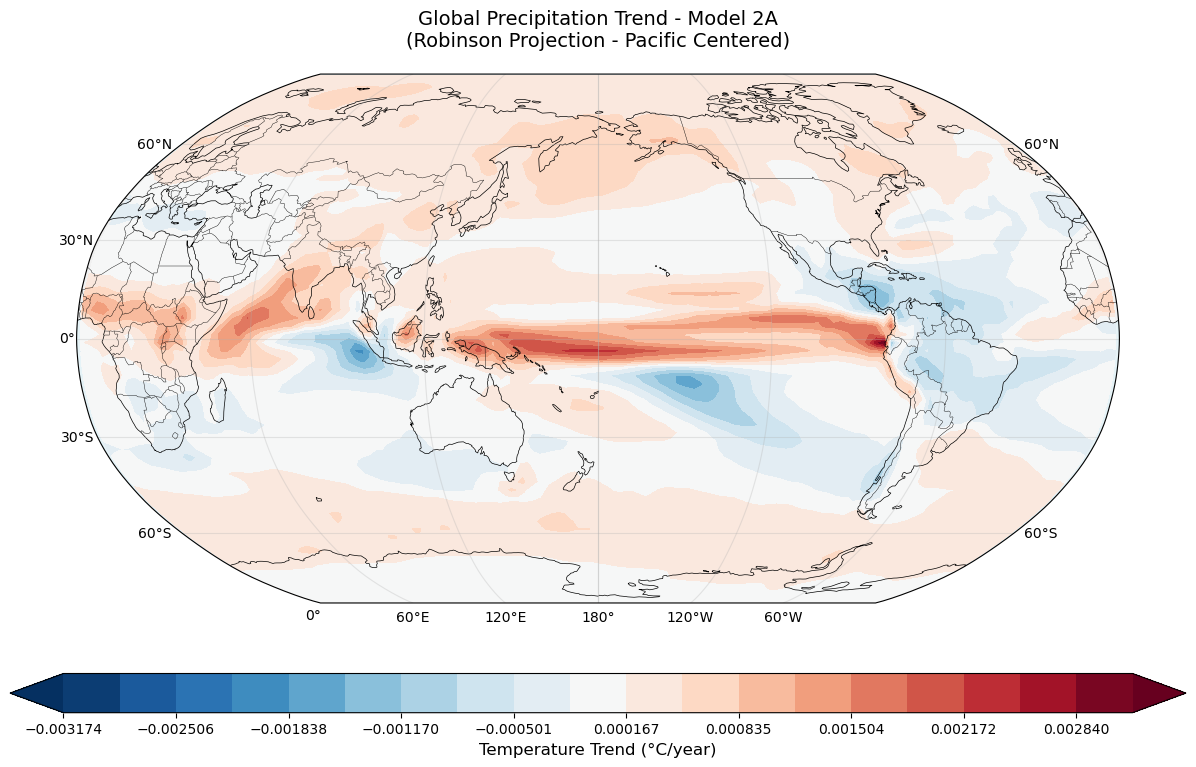

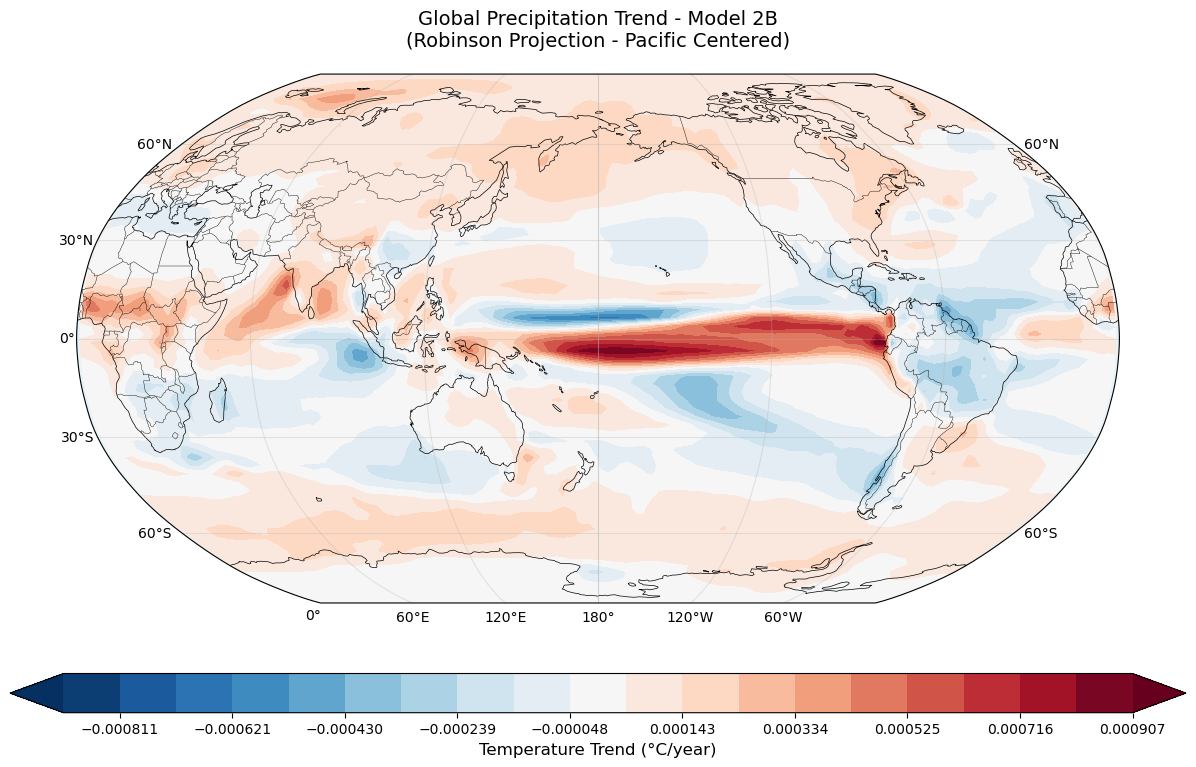

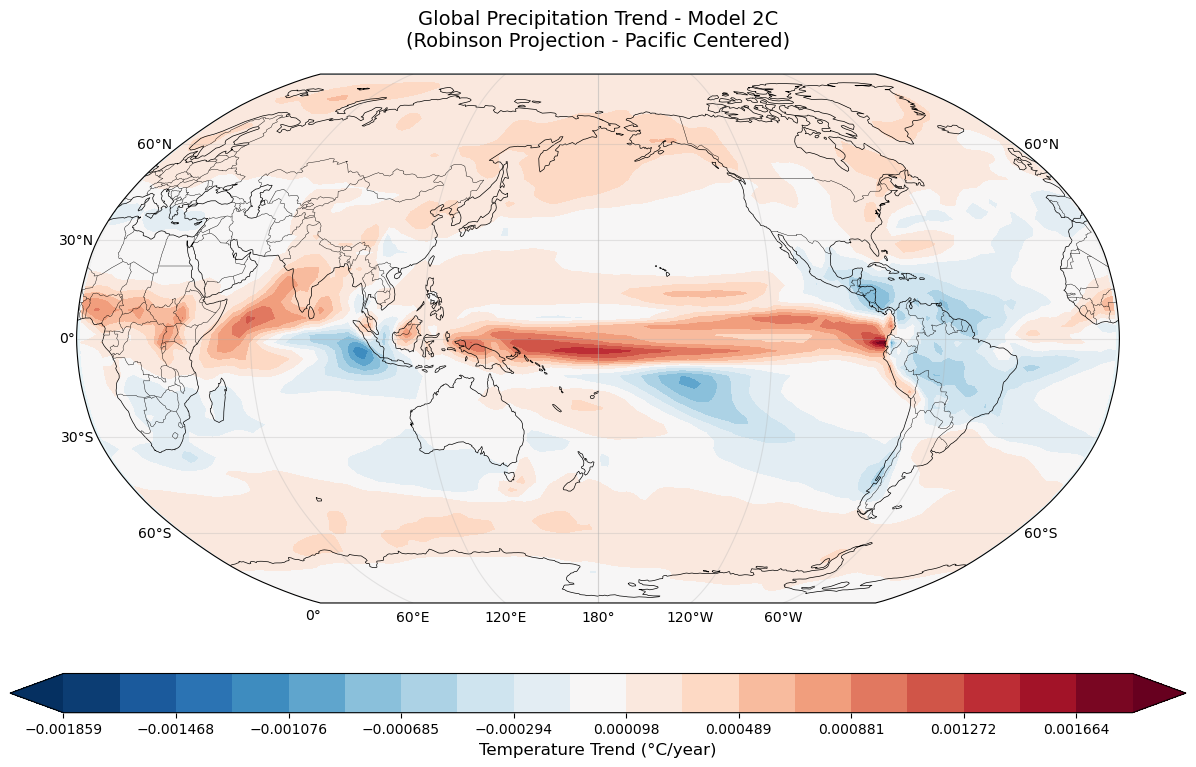

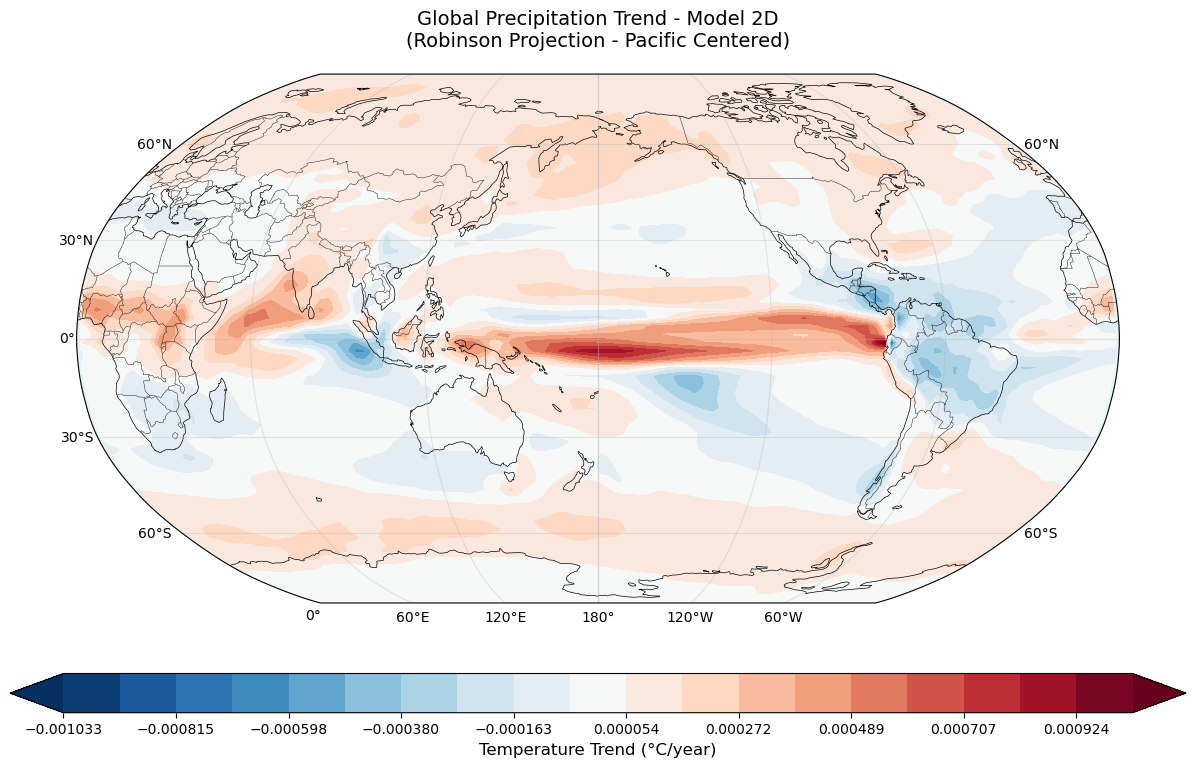

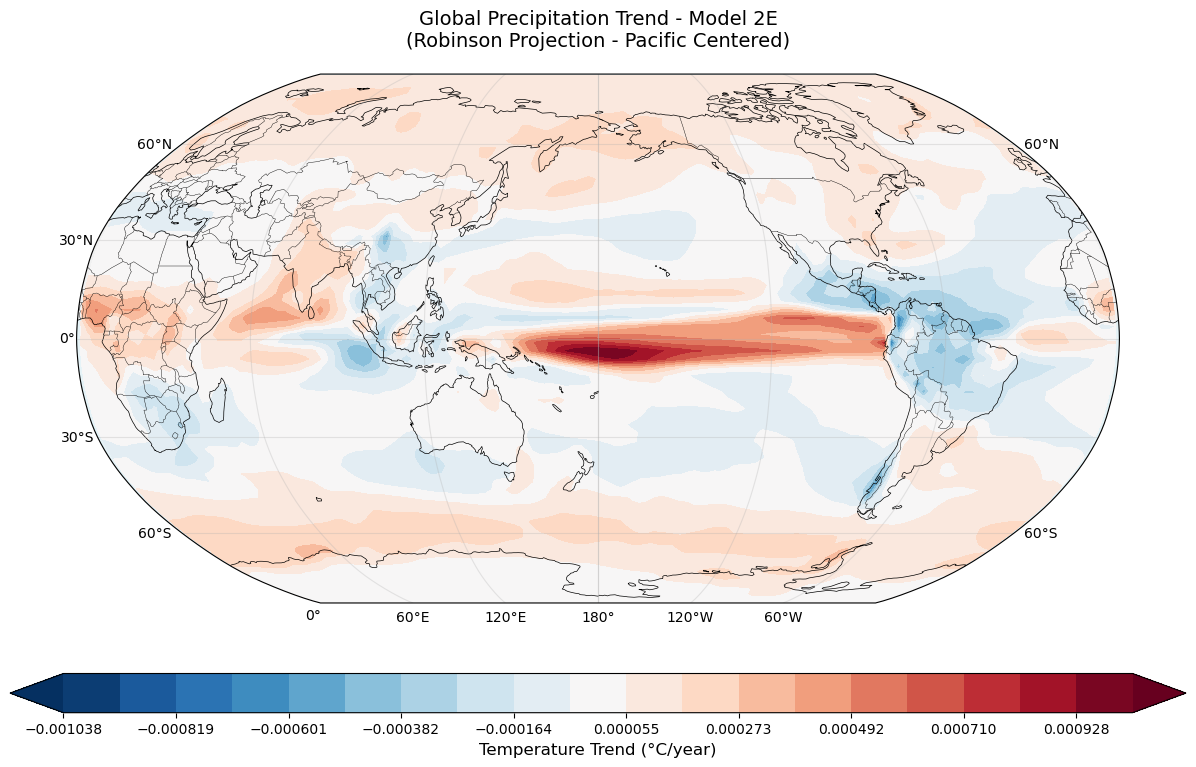

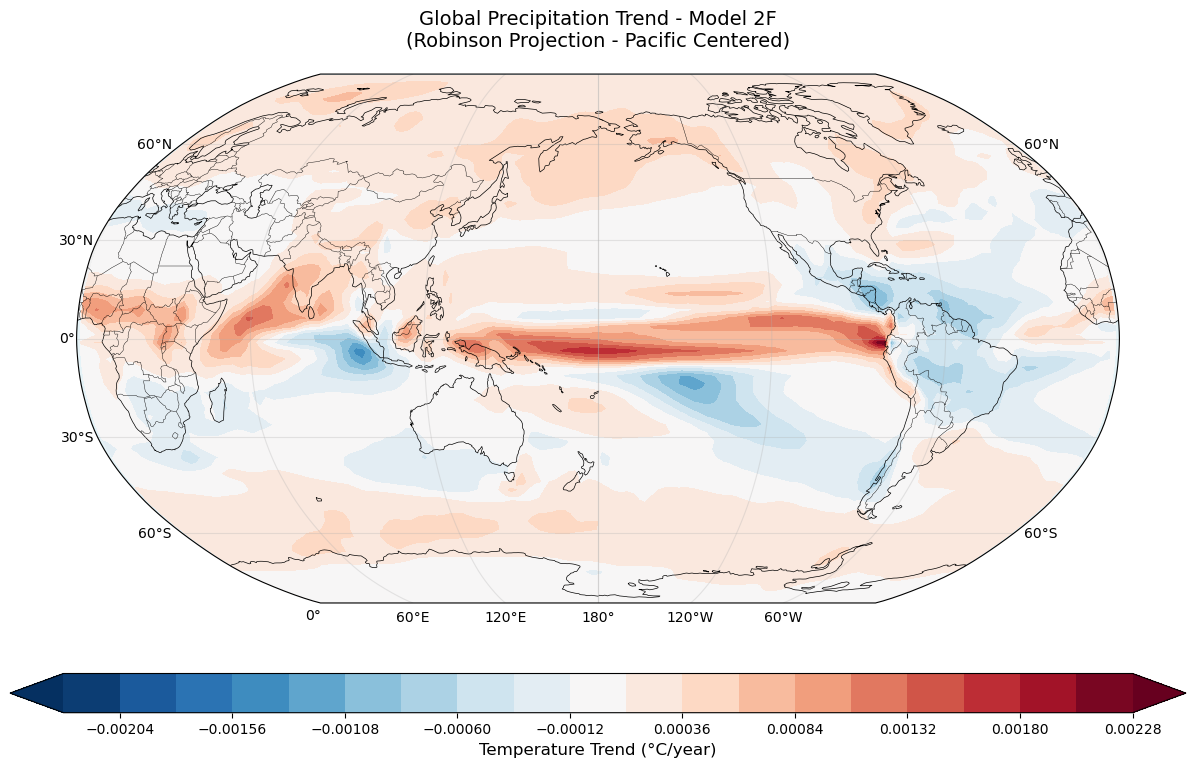

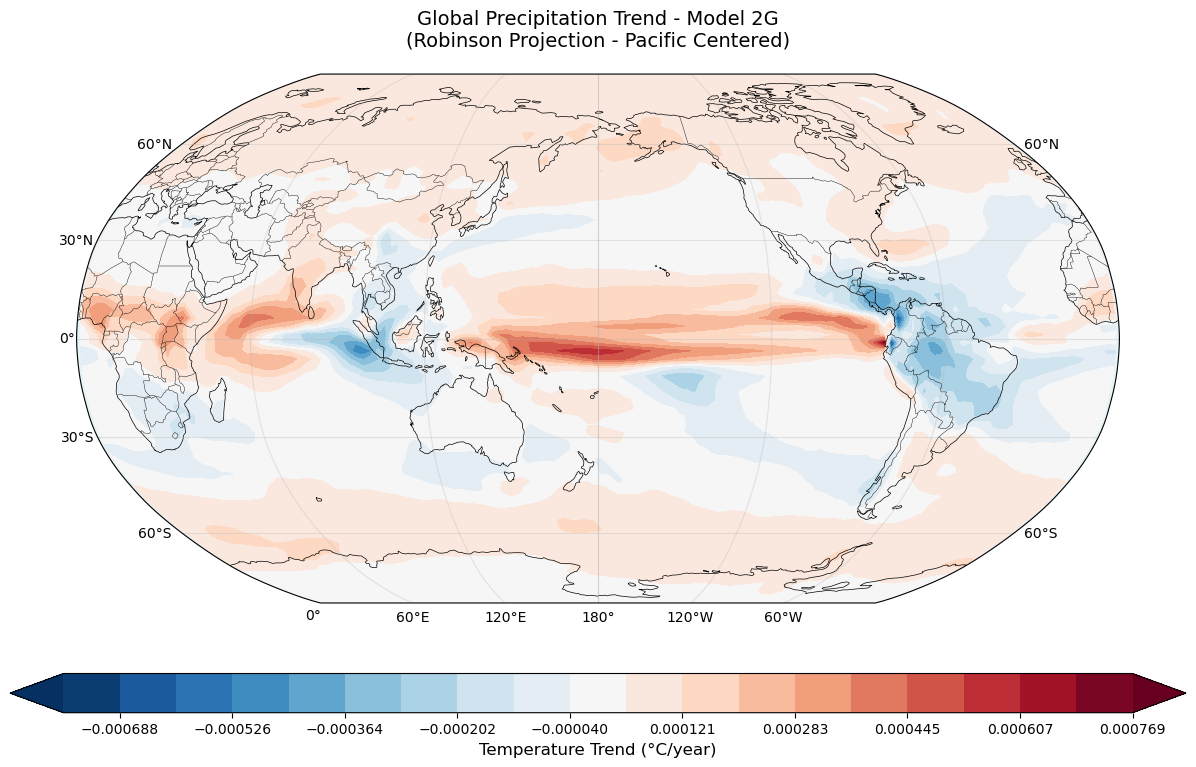

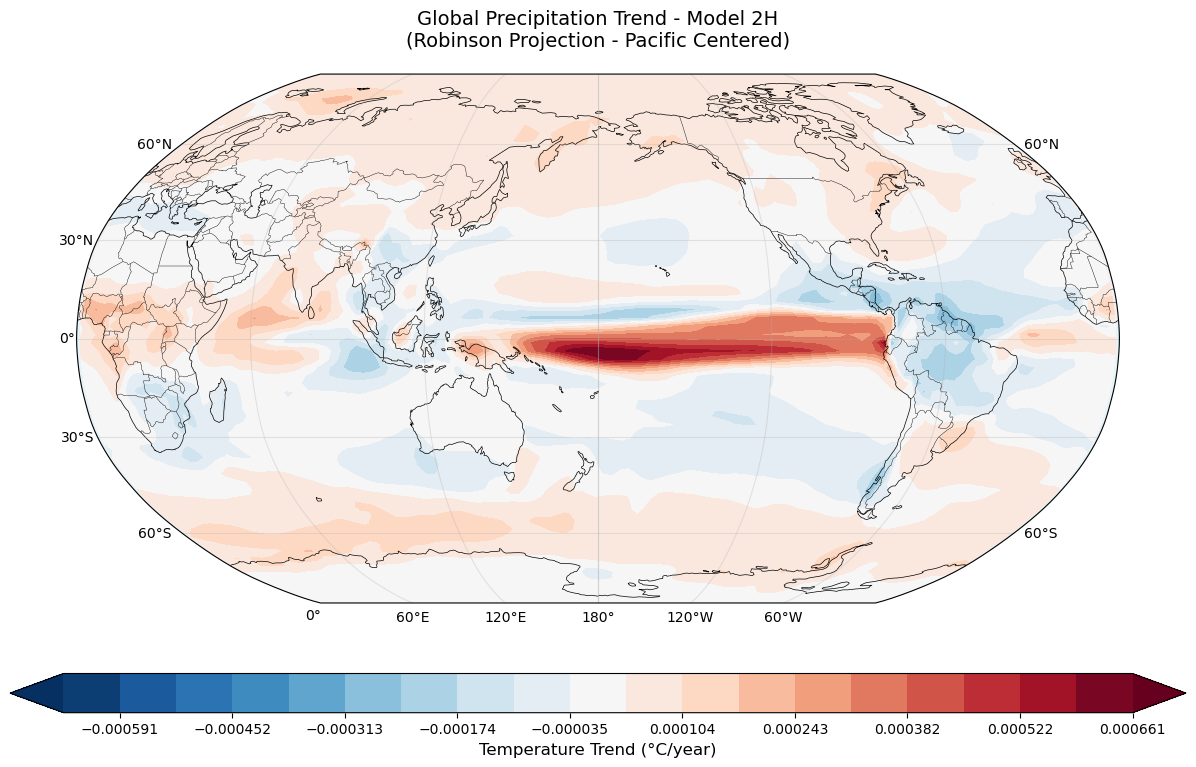

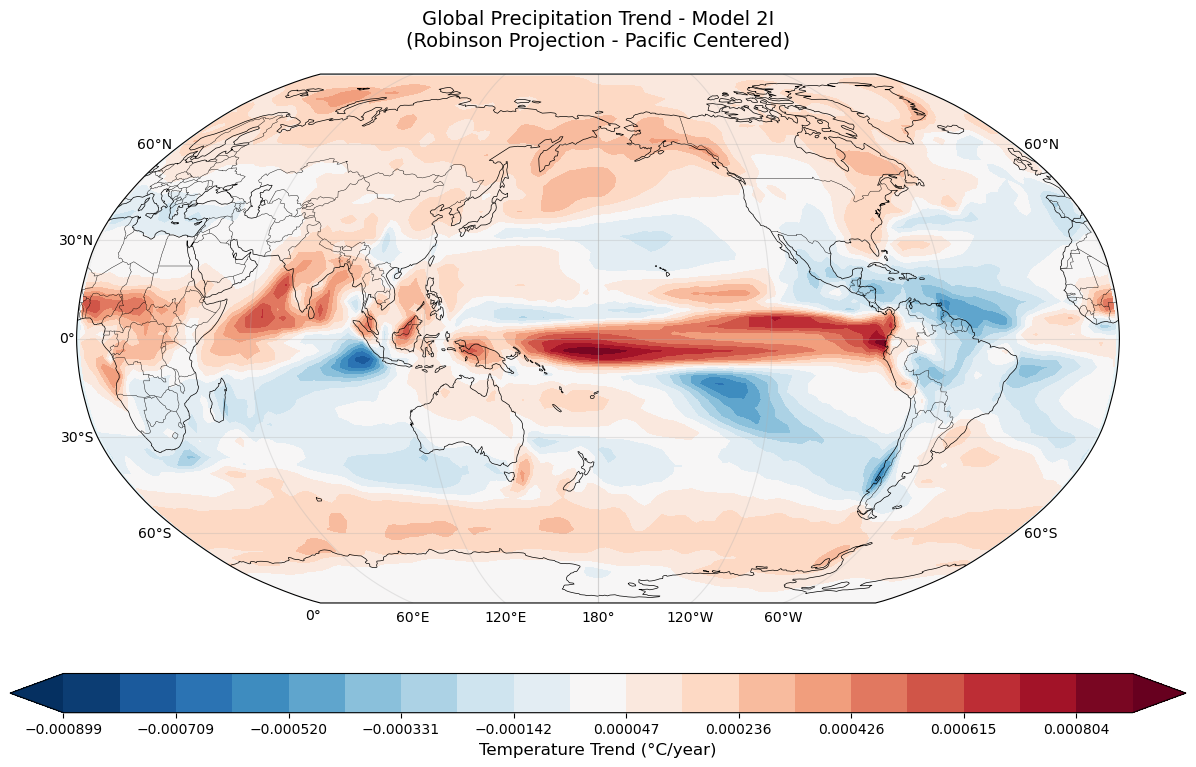

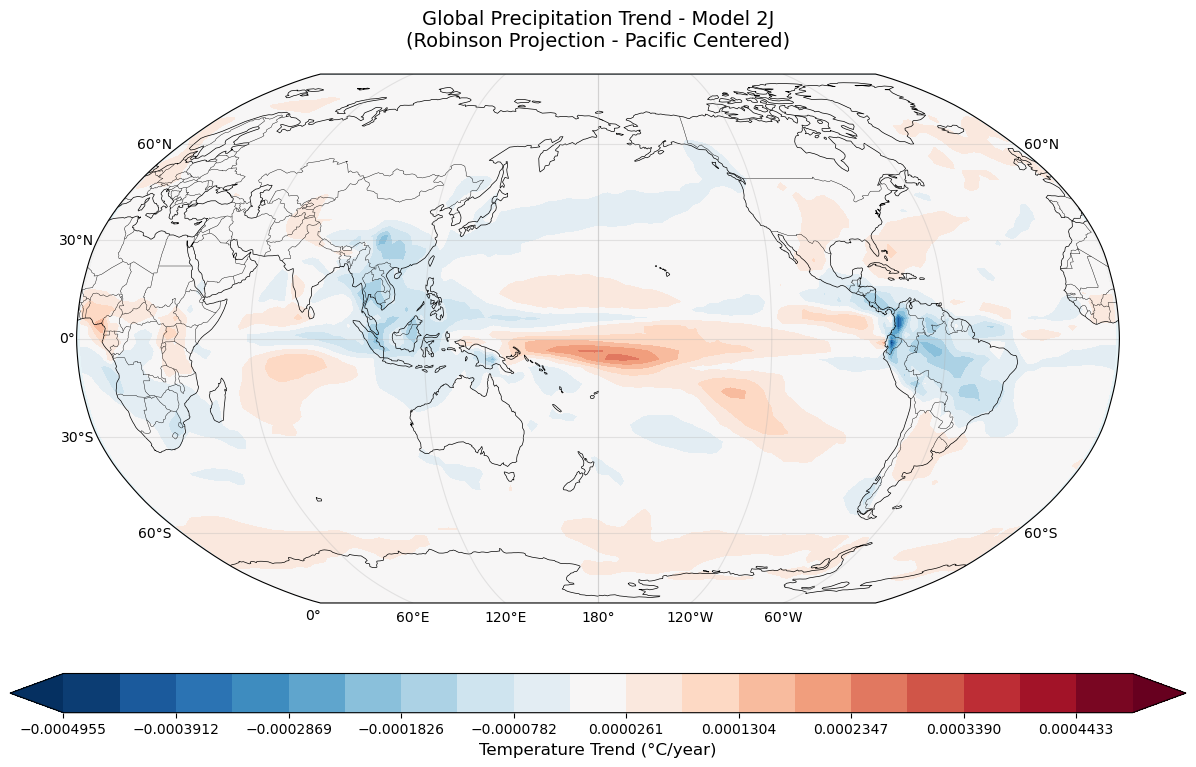

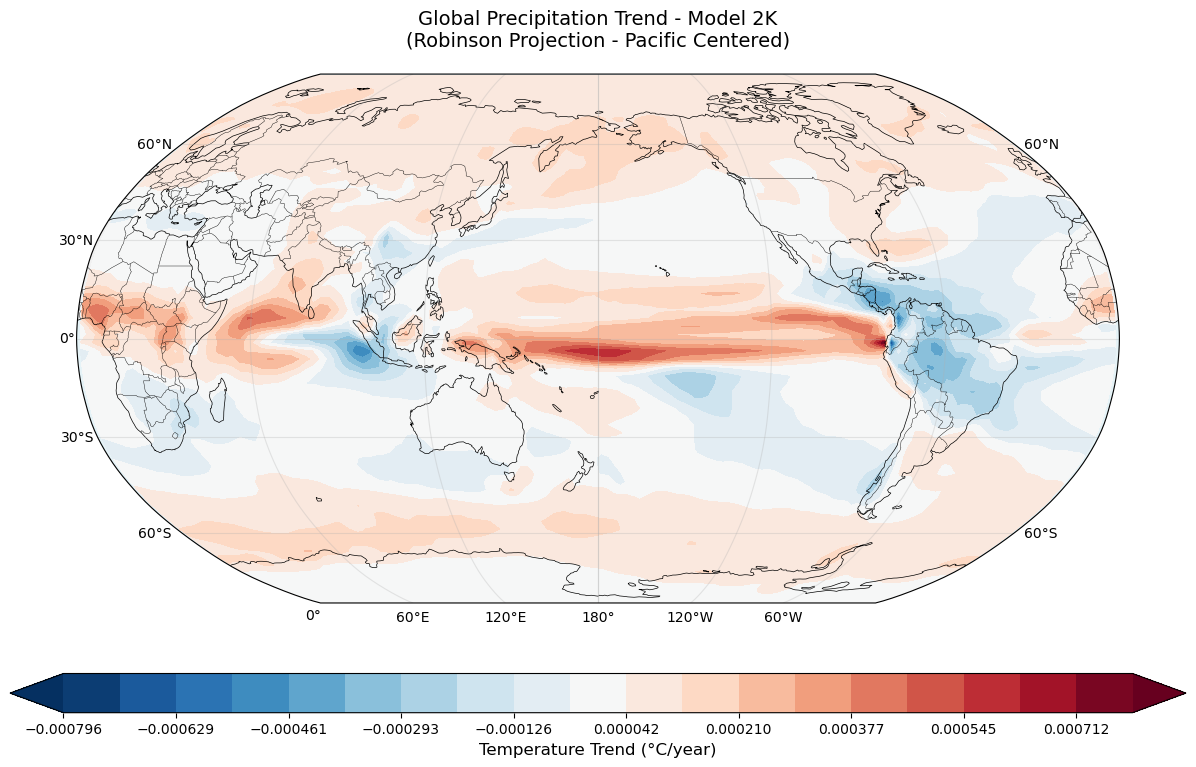

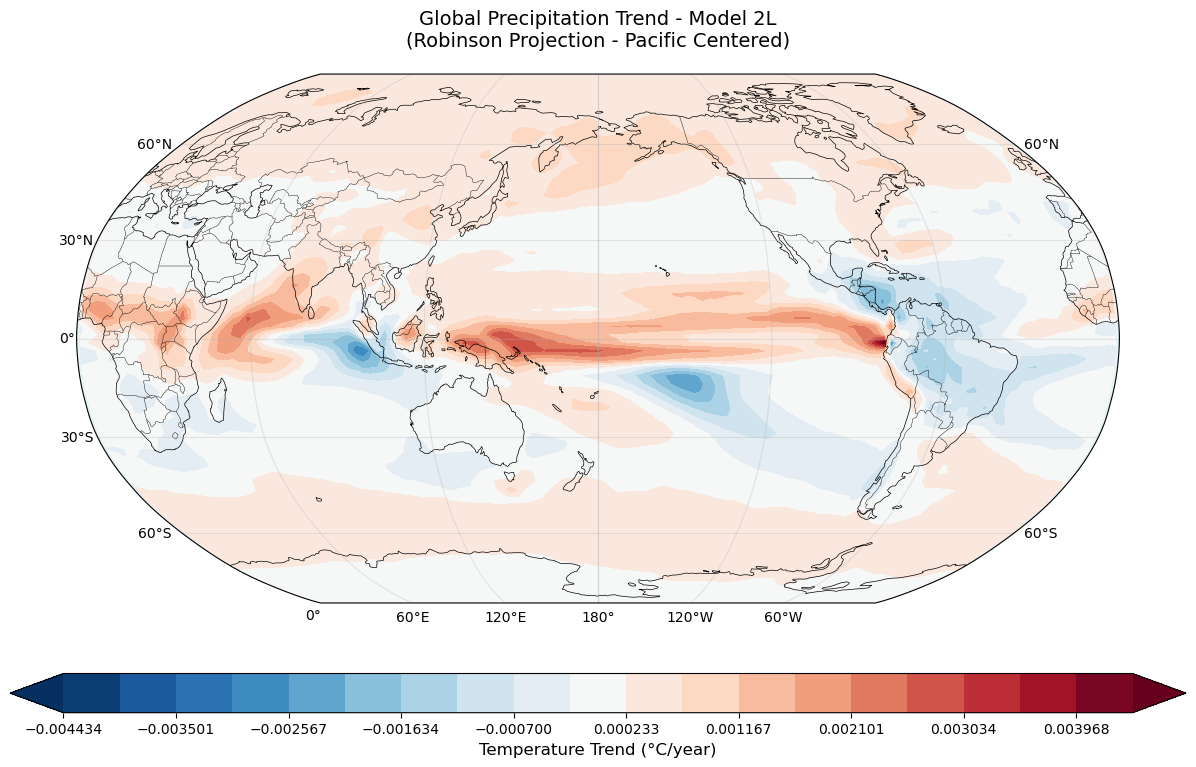

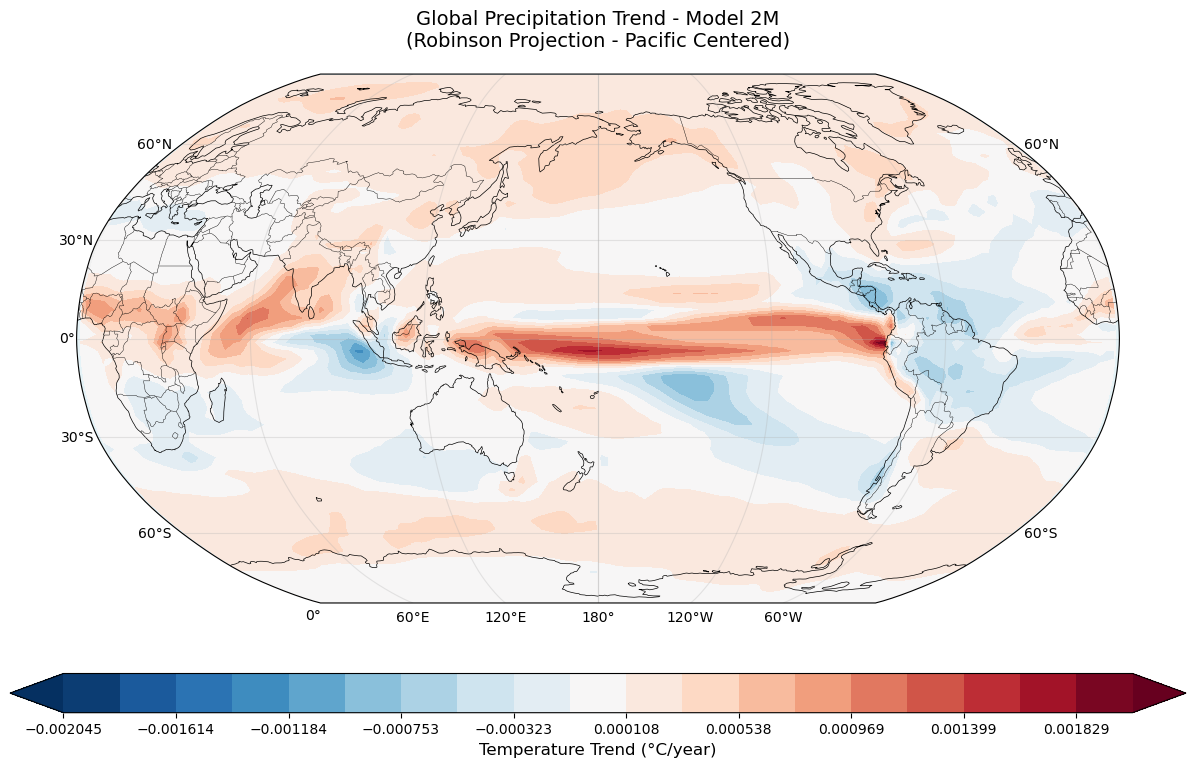

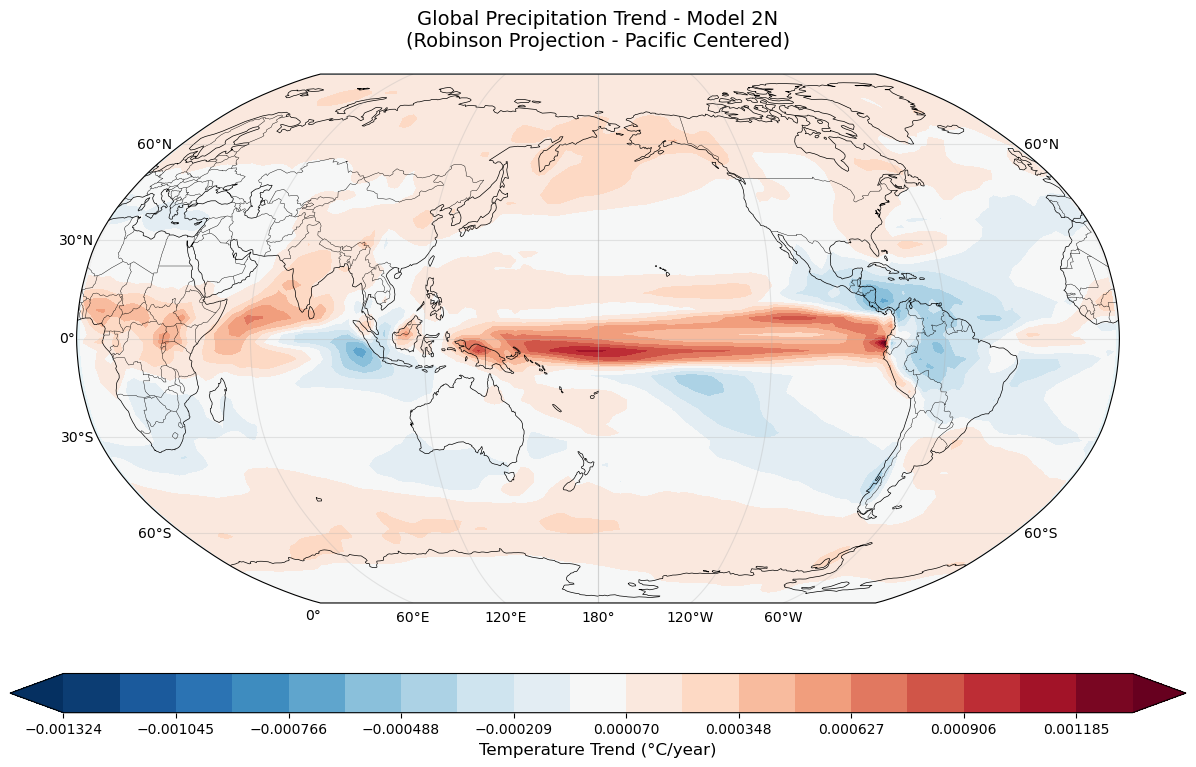

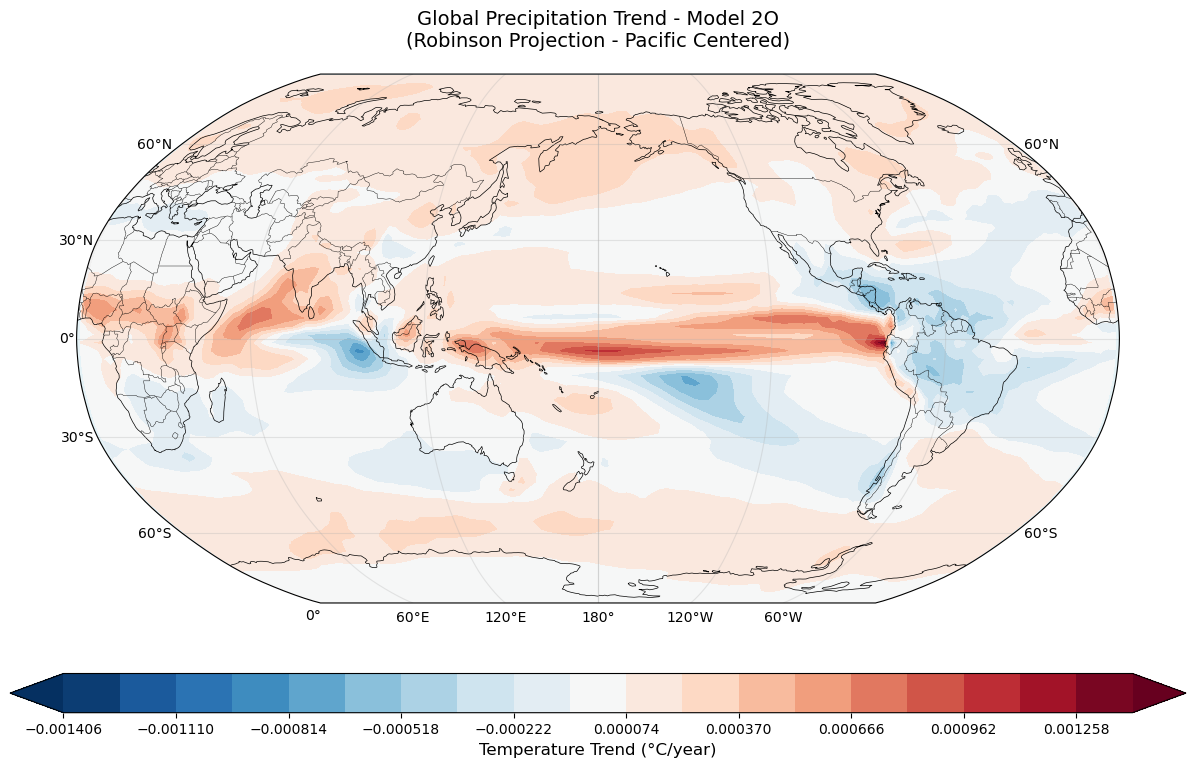

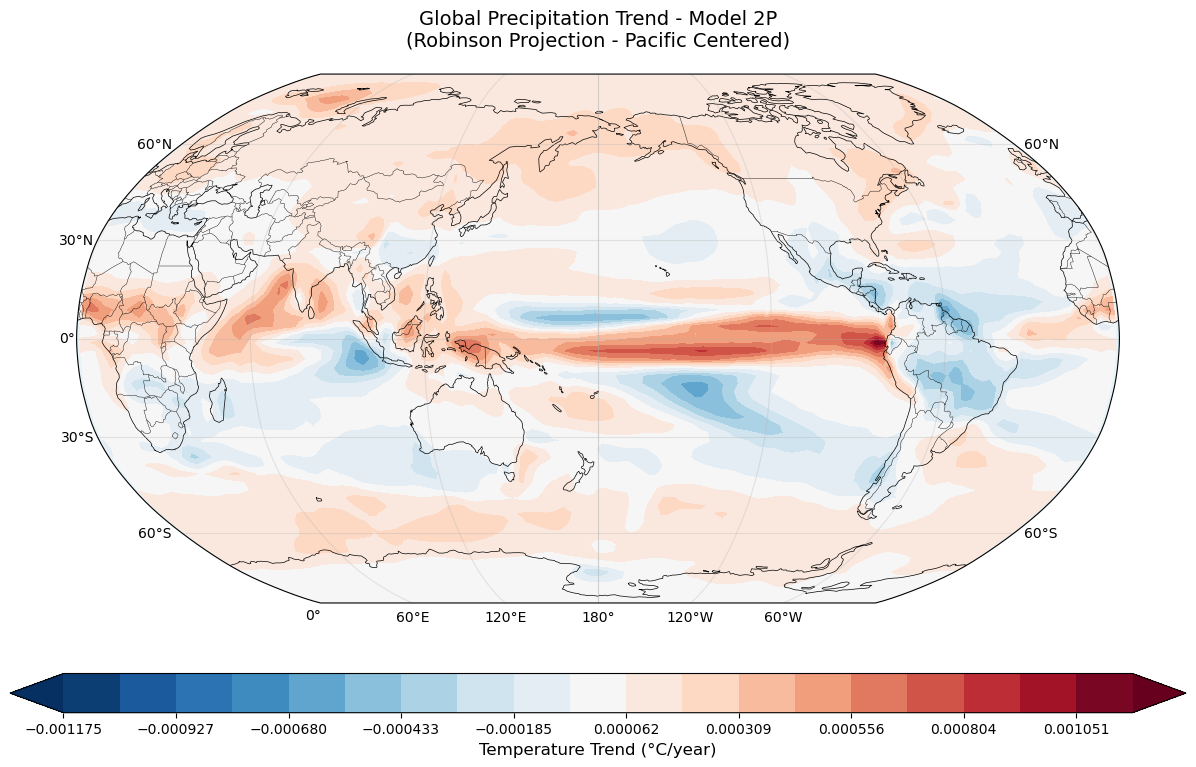

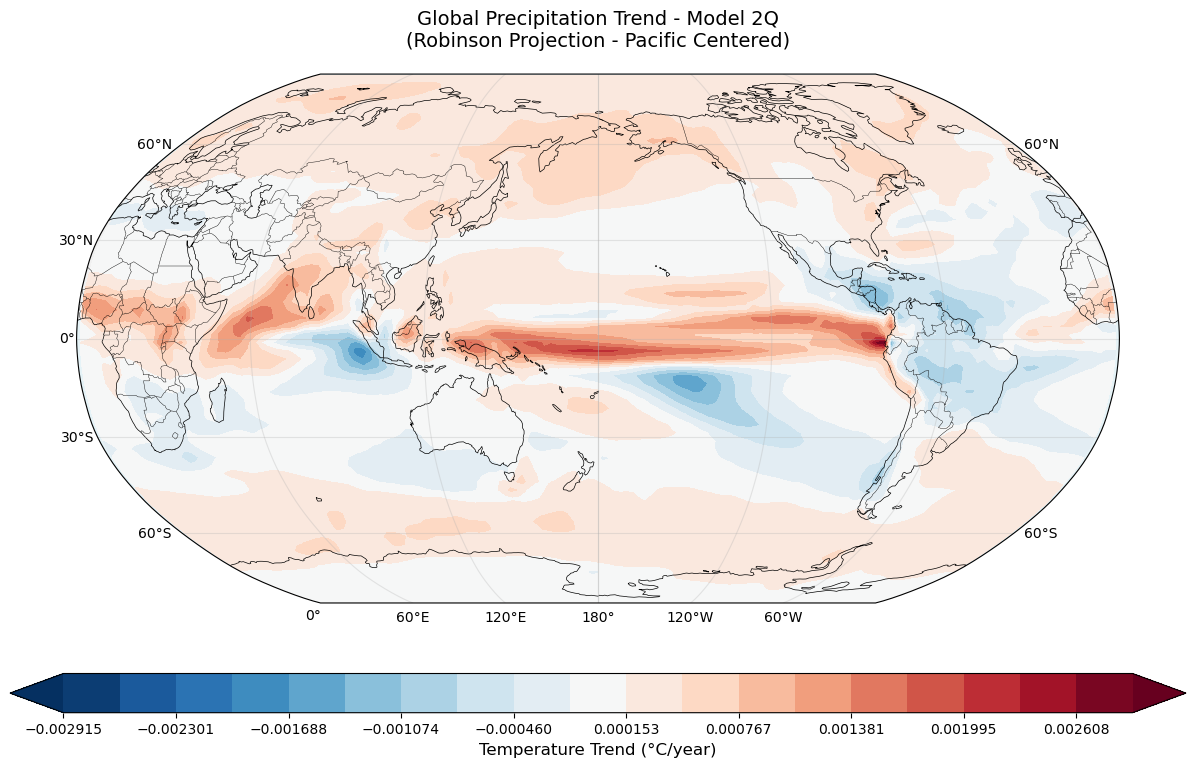

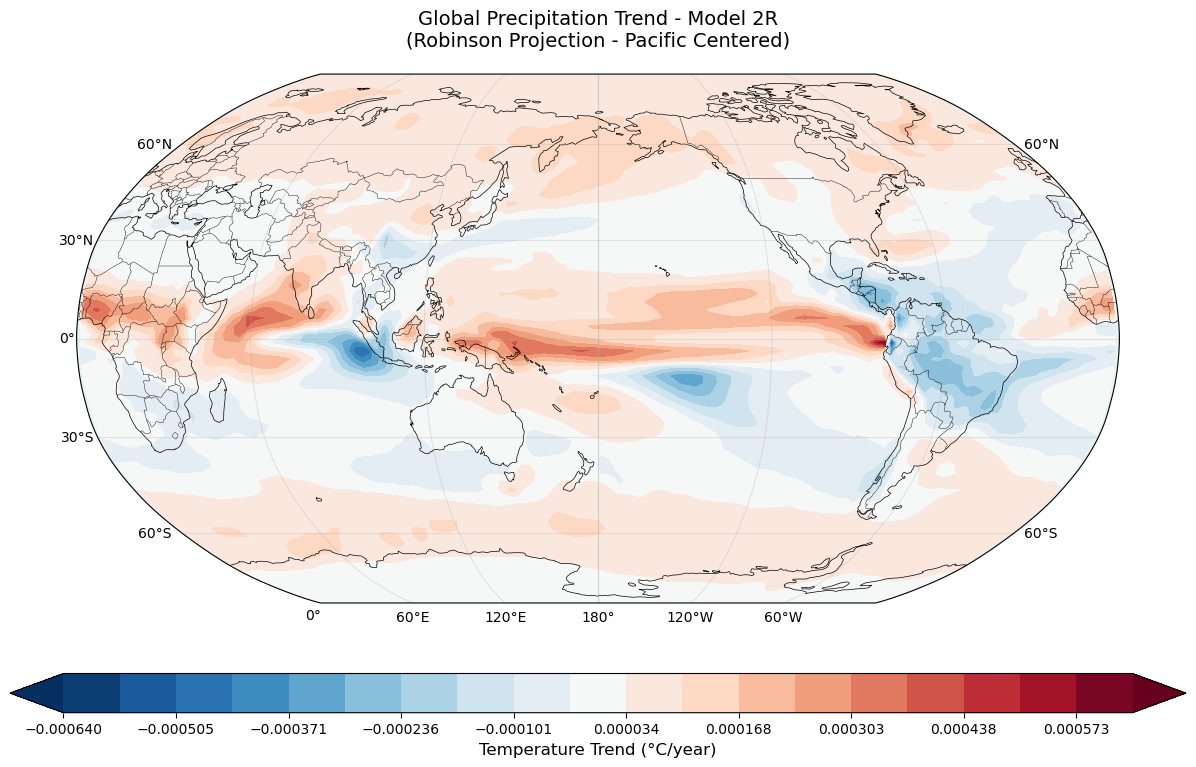

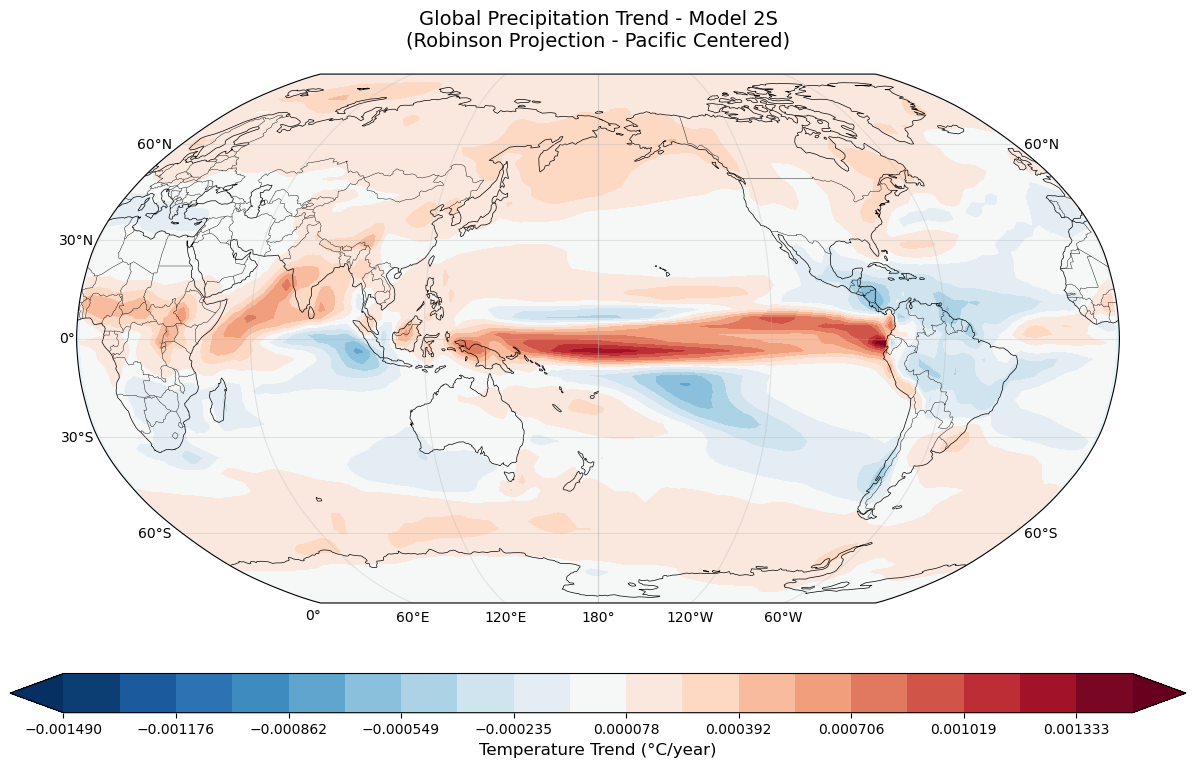

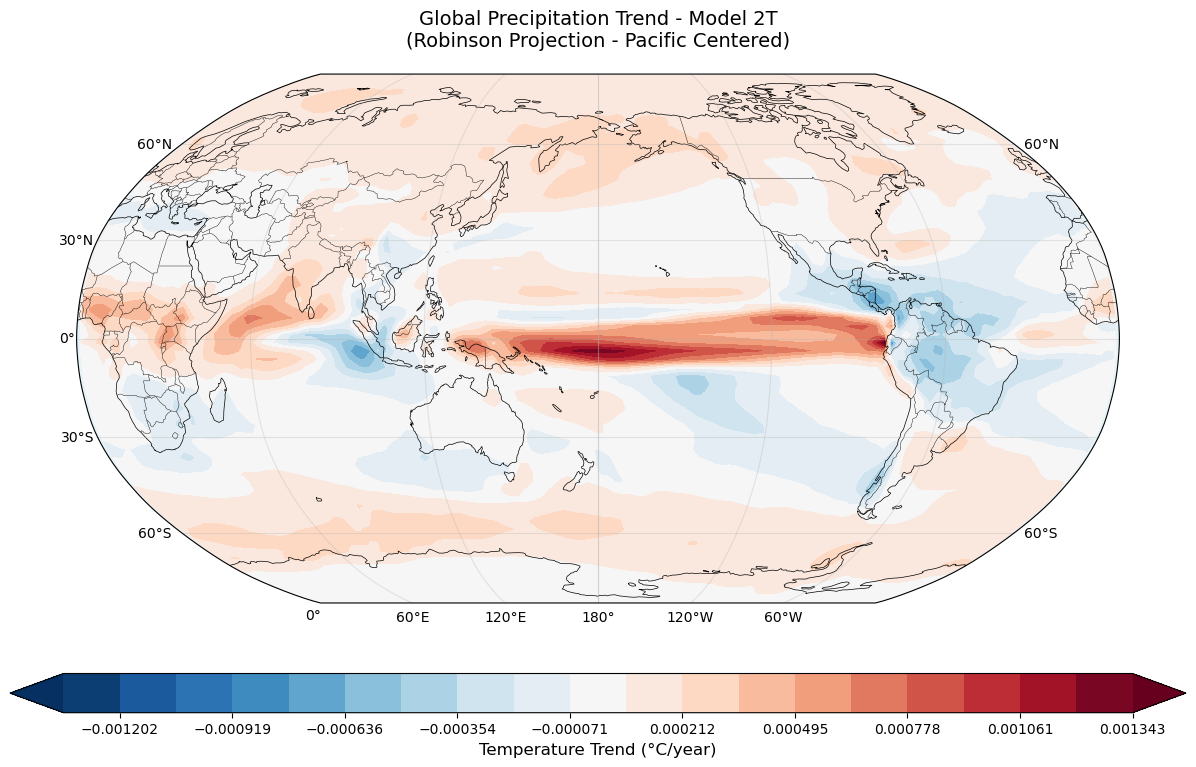

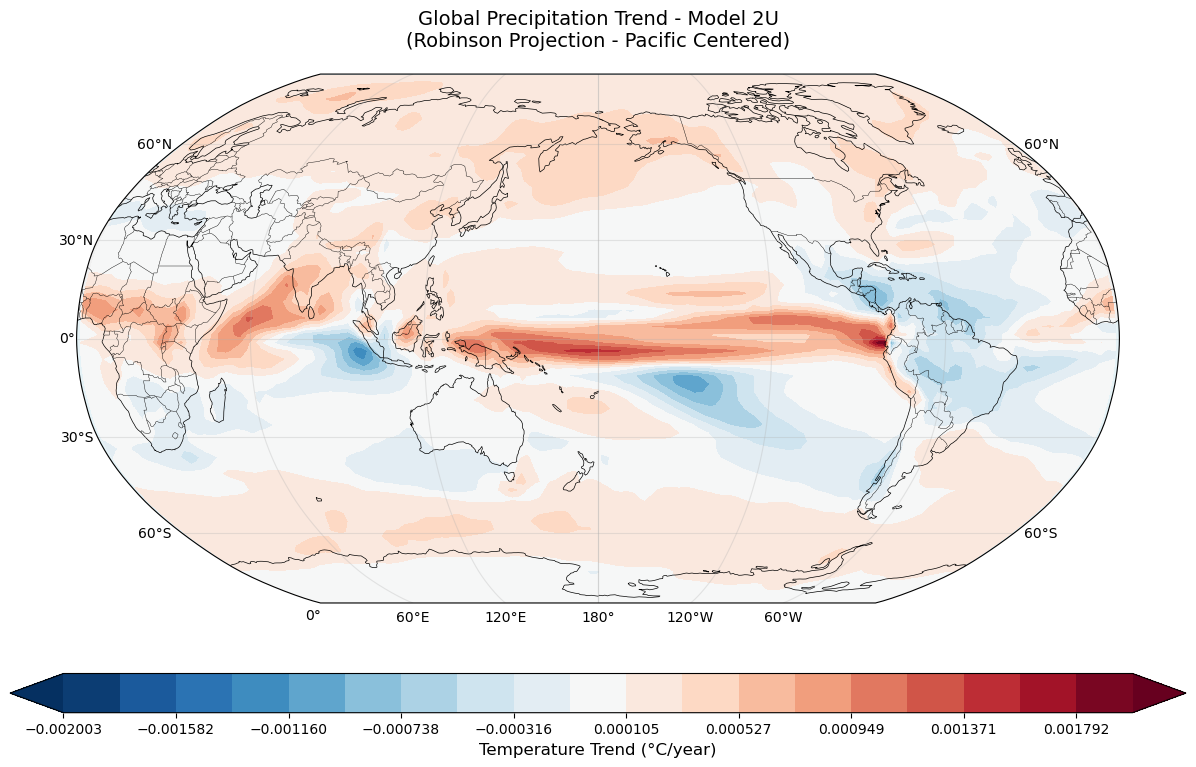

In [20]:
# display the trend map for the first test model
for idx_run in range(trends_ridge_smooth_fullmap.shape[0]):
    fig = visualizer.plot_robinson_projection(trends_ridge_fullmap, 
                                    title="Global Precipitation Trend",
                                    cmap='RdBu_r',
                                    run_idx=idx_run,
                                    central_longitude=180)

## Cross validation to select the best combination (ridge penalty param, rank)

In [ ]:
## 6.5 Cross-Validation to get the best Lambda Optimization

print("="*70)
print("         CROSS-VALIDATION LAMBDA OPTIMIZATION")
print("="*70)

# Import the cross-validation function
from algorithms import cross_validation_lambda_optimization, cross_validation_lambda_rank_optimization,\
                        plot_cv_lambda_results, plot_cv_lambda_rank_results

# Define lambda values to test (broader range for better optimization)
lambda_values_cv = [1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0]


print("Performing cross-validation to optimize lambda for worst-case performance...")

# Optimize lambda using cross-validation with worst-case objective


cv_optimization = cross_validation_lambda_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)

# Plot cross-validation results
fig_cv = plot_cv_lambda_results(cv_optimization, figsize=(18, 5))
plt.show()


# Extract optimal lambda
optimal_lambda_cv = cv_optimization['best_lambda']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['mean_nrmse']:.4f}")

         CROSS-VALIDATION LAMBDA OPTIMIZATION
Performing cross-validation to optimize lambda for worst-case performance...
Cross-validation with 5 folds for 1 lambda values...
Optimization objective: worst_case
  Testing λ = 10.0


KeyboardInterrupt: 

In [ ]:
## 6.5 Cross-Validation Lambda Optimization
print("="*70)
print("         CROSS-VALIDATION LAMBDA OPTIMIZATION")
print("="*70)

# Define lambda values to test (broader range for better optimization)
lambda_values_cv = [1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0]
rank_values_cv = [5, 10, 15, 20, 25, 30, 50]




print("Performing cross-validation to optimize lambda and rank for worst-case performance...")

# Optimize lambda and rank using cross-validation with worst-case objective
cv_optimization_lr = cross_validation_lambda_rank_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    rank_values=rank_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)

# # Plot cross-validation results
fig_cv = plot_cv_lambda_rank_results(cv_optimization_lr, figsize=(18, 5))
plt.show()

# Extract optimal lambda
optimal_lambda_cv_lr = cv_optimization_lr['best_lambda']
optimal_rank_cv_lr = cv_optimization_lr['best_rank']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv_lr}")
print(f"🎯 OPTIMAL RANK (CV-optimized): {optimal_rank_cv_lr}")
print(f"   Worst-case NRMSE: {cv_optimization_lr['cv_results'][(optimal_lambda_cv_lr, optimal_rank_cv_lr)]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization_lr['cv_results'][(optimal_lambda_cv_lr, optimal_rank_cv_lr)]['mean_nrmse']:.4f}")

         CROSS-VALIDATION LAMBDA OPTIMIZATION
Performing cross-validation to optimize lambda and rank for worst-case performance...
Cross-validation with 5 folds for 1 lambda values...
Optimization objective: worst_case
  Testing λ = 10.0

Setting up low-rank solver...
Computing SVD for low-rank approximations...
Solving ridge regression with λ=10.0
Input shape: X=torch.Size([29835, 10368]), Y=torch.Size([29835, 10368])
Reshaped: X=torch.Size([29835, 10368]), Y=torch.Size([29835, 10368])


Ridge weights computed: torch.Size([10368, 10368])
SVD computed: U=torch.Size([40203, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000015 to 6860.553223
Computed solutions for ranks: [10]

Setting up low-rank solver...
Computing SVD for low-rank approximations...
Solving ridge regression with λ=10.0
Input shape: X=torch.Size([35360, 10368]), Y=torch.Size([35360, 10368])
Reshaped: X=torch.Size([35360, 10368]), Y=torch.Size([35360, 10368])
Ridge weights computed: torch.Size([10368, 10368])


In [ ]:
# given the best lambda value, run the ridge regression again
w_ridge_cv = ridge_regression(x_train_merged_filtered,y_train_merged_filtered, optimal_lambda_cv, verbose=True)


# given the best lambda and best rank, run the low-rank solver again
w_ridge_lr_cv =  ridge_regression(x_train_merged_filtered,y_train_merged_filtered, optimal_lambda_cv_lr, verbose=True)


lr_solver_cv = LowRankSolver()
lr_solver_cv.fit(x_train_merged_filtered, y_train_merged_filtered, w_ridge_lr_cv, verbose=True)
lr_solver_cv_solution = lr_solver_cv.get_multiple_ranks([optimal_rank_cv_lr], verbose=True)

Solving ridge regression with λ=10.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Ridge weights computed: torch.Size([10368, 10368])
Solving ridge regression with λ=10.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Ridge weights computed: torch.Size([10368, 10368])


In [ ]:
# build the concatenation of (X, sqrt{lambda} I_p)
S_inv = torch.eye(x_train_merged_filtered.shape[1], dtype=x_train_merged_filtered.dtype, device=x_train_merged_filtered.device)

I_p = torch.eye(x_train_merged_filtered.shape[1], dtype=x_train_merged_filtered.dtype, device=x_train_merged_filtered.device)
x_augmented = torch.cat([x_train_merged_filtered, torch.sqrt(torch.tensor(optimal_lambda_cv_lr, dtype=x_train_merged_filtered.dtype, device=x_train_merged_filtered.device)) * I_p], dim=0)
U, S, Vt = torch.linalg.svd(x_augmented @ w_ridge_lr_cv, full_matrices=False)

In [ ]:
# Make predictions using different methods

# first compute the temporal means for the filtered indices
temporal_means = temporal_means.reshape(temporal_means.shape[0], temporal_means.shape[1], -1)
temporal_means = temporal_means[:,:,notnan_idx]


print("Making predictions...")
# Global models
y_pred_ridge = (x_test_filtered @ w_ridge + temporal_means).reshape(x_test.shape[0], x_test.shape[1], latitude.shape[0], longitude.shape[0])
y_pred_ridge_lr = (x_test_filtered @ w_ridge_lr + temporal_means).reshape(x_test.shape[0], x_test.shape[1], latitude.shape[0], longitude.shape[0])

y_pred_ridge_smooth = (x_test_smooth @ w_ridge + temporal_means).reshape(x_test.shape[0], x_test.shape[1], latitude.shape[0], longitude.shape[0])
y_pred_ridge_lr_smooth = (x_test_smooth @ w_ridge_lr + temporal_means).reshape(x_test.shape[0], x_test.shape[1], latitude.shape[0], longitude.shape[0])

Making predictions...


/tmp/ipykernel_14899/2239845749.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred_ridge = (x_test_filtered @ w_ridge + temporal_means).reshape(x_test.shape[0], x_test.shape[1], latitude.shape[0], longitude.shape[0])
/tmp/ipykernel_14899/2239845749.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred_ridge_lr = (x_test_filtered @ w_ridge_lr + temporal_means).reshape(x_test.shape[0], x_test.shape[1], latitude.shape[0], longitude.shape[0])
/tmp/ipykernel_14899/2239845749.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred_ridge_smooth = (x_test_smooth @ w_ridge + temporal_means).reshape(x_test.shape[0], x_test.shape[1], latitude.shape[0], longitude.shape[0])
/tmp/ipykernel_14899/2239845749.py:9: 

In [ ]:
# save the forced response predictions into a netcdf file

import xarray as xr
import pandas as pd

# convert numpy arrays to xarray DataArrays
def to_xarray(data, model_names, longitude, latitude):
    time = pd.date_range(start='1850-01-01', periods=data.shape[1], freq='ME')
    data_xr = xr.DataArray(
        data,
        dims=['model', 'time', 'latitude','longitude'],
        coords={
            'model': model_names,
            'time': time,
            'longitude': longitude,
            'latitude': latitude
        }
    )

    lon_xr = xr.DataArray(
        longitude,
        dims=['lon'],
        coords={'lon': longitude}
    )
    
    lat_xr = xr.DataArray(
        latitude,
        dims=['lat'],
        coords={'lat': latitude}
    )
    
    return data_xr, lon_xr, lat_xr



In [ ]:
# Convert to Dataset with a custom variable name
y_pred_ridge_xr, lon_xr, lat_xr = to_xarray(y_pred_ridge, test_models, longitude, latitude)
y_pred_ridge_xr.to_dataset(name='prediction').to_netcdf('/home/vcohen/cope/results/tier2/predictions_psl_ridge_tier2.nc')
y_pred_ridge_lr_xr, lon_xr, lat_xr = to_xarray(y_pred_ridge_lr, test_models, longitude, latitude)
y_pred_ridge_lr_xr.to_dataset(name='prediction').to_netcdf('/home/vcohen/cope/results/tier2/predictions_psl_ridge_lr_tier2.nc')

y_pred_ridge_smooth_xr, lon_xr, lat_xr = to_xarray(y_pred_ridge_smooth, test_models, longitude, latitude)
y_pred_ridge_smooth_xr.to_dataset(name='prediction').to_netcdf('/home/vcohen/cope/results/tier2/predictions_psl_ridge_smooth_tier2.nc')
y_pred_ridge_lr_smooth_xr, lon_xr, lat_xr = to_xarray(y_pred_ridge_lr_smooth, test_models, longitude, latitude)
y_pred_ridge_lr_smooth_xr.to_dataset(name='prediction').to_netcdf('/home/vcohen/cope/results/tier2/predictions_psl_ridge_lr_smooth_tier2.nc')

In [ ]:
# save it as a netcdf file
path_tier2 = '/home/vcohen/cope/results/tier2/'

y_pred_ridge_xr.to_netcdf(f'{path_tier2}predictions_{variable}_ridge_tier2.nc')
y_pred_ridge_lr_xr.to_netcdf(f'{path_tier2}predictions_{variable}_ridge_lr_tier2.nc')
y_pred_ridge_smooth_xr.to_netcdf(f'{path_tier2}predictions_{variable}_ridge_smooth_tier2.nc')
y_pred_ridge_lr_smooth_xr.to_netcdf(f'{path_tier2}predictions_{variable}_ridge_lr_smooth_tier2.nc')